<center>

# **Министерство науки и высшего образования Российской Федерации**

# ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ АВТОНОМНОЕ ОБРАЗОВАТЕЛЬНОЕ УЧРЕЖДЕНИЕ ВЫСШЕГО ОБРАЗОВАНИЯ

# **НАЦИОНАЛЬНЫЙ ИССЛЕДОВАТЕЛЬСКИЙ УНИВЕРСИТЕТ ИТМО**

# ITMO University


## ФАКУЛЬТЕТ ПРИКЛАДНОЙ ИНФОРМАТИКИ

&nbsp;

&nbsp;

### Отчет по лабораторной работе №3
### по дисциплине «Алгоритмы и структуры данных»
### Тема: Графы
### Вариант 7

&nbsp;

&nbsp;

</center>

<div style="text-align: right;">

**Выполнила:**<br>
Макарова Е. В.<br>
АиСД K25 МСТ 1.1

&nbsp;

**Проверил:**
Царьков Г. И.
</div>

&nbsp;

&nbsp;

<center>

Санкт-Петербург<br>
2026 г.

</center>

<center>

## Содержание отчета

</center>

| | Страница |
|---|---|
| **Задачи по варианту** | |
| &emsp;Задача №1. Лабиринт [1 балл] | |
| &emsp;Задача №10. Оптимальный обмен валюты [2 балла] | |
| &emsp;Задача №14. Автобусы [3 балла] | |
| **Дополнительные задачи** | |
| &emsp;Задача №13. Грядки [3 балла] | |
| &emsp;Задача №15. Герои [3 балла] | |
| &emsp;Задача №17. Слабая К-связность [4 балла] | |
| &emsp;Задача №18. Построение дорог [4 баллов] | |
| &emsp;Задача №19. Кластеризация [4 баллов] | |
| **Вывод** | |

In [ ]:
import time, tracemalloc, os, math
from google.colab import drive
from collections import deque


drive.mount('/content/drive', force_remount=True)
path = r'/content/drive/MyDrive/Отчеты 2025 26/Макарова Ева Викторовна 1.1/Лабораторная №3/'

def time_memory_decorator(func):
    def wrapper():
        t_start = time.time()
        res = func()
        print(f"Время работы программы: {time.time() - t_start:.2f}")
        tracemalloc.start()
        func()
        current, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        print(f"Текущий объем памяти: {current / 2 ** 20:.2f} Mбайт, "
              f"максимальный объем выделенной памяти: {peak / 2 ** 20:.2f} Mбайт\n")
        return res

    return wrapper

Mounted at /content/drive


<center>

## Задачи по варианту

</center>

---

### Задача №1. Лабиринт  [1 балл]

Лабиринт представляет собой прямоугольную сетку ячеек со стенками между некоторыми соседними ячейками.
Вы хотите проверить, существует ли путь от данной ячейки к данному выходу из лабиринта, где выходом также
является ячейка, лежащая на границе лабиринта (в примере, показанном на рисунке, есть два выхода: один на левой
границе и один на правой границе). Для этого вы представляете лабиринт в виде неориентированного графа: вершины
графа являются ячейками лабиринта, две вершины соединены неориентированным ребром, если они смежные и между
ними нет стены. Тогда, чтобы проверить, существует ли путь между двумя заданными ячейками лабиринта, достаточно
проверить, что существует путь между соответствующими двумя вершинами в графе.

Вам дан неориентированный граф и две различные вершины u и v. Проверьте, есть ли путь между u и v.
• Формат ввода / входного файла (input.txt). Неориентированный граф с n вершинами и m ребрами по формату 1. Следующая строка после ввода всго графа содержит две вершины u и v.

• Ограничения на входные данные. 2 ≤ n ≤ $10^3$
, 1 ≤ m ≤ $10^3$
, 1 ≤ u, v ≤ n, u ̸= v.

• Формат вывода / выходного файла (output.txt). Выведите 1, если есть путь между вершинами u и v; выведите
0, если пути нет.

• Ограничение по времени. 5 сек.

• Ограничение по памяти. 512 мб.

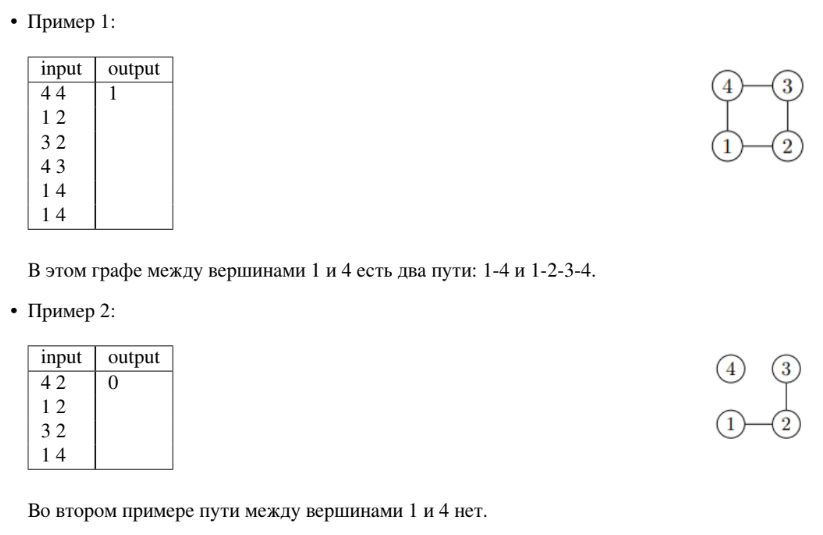

**Листинг кода:**


In [ ]:
@time_memory_decorator
def solve():
    with open(input_file) as inp:
        n, m = map(int, inp.readline().split())

        # Создаём список смежности
        graph = [[] for _ in range(n + 1)]

        for i in range(m):
            a, b = map(int, inp.readline().split())
            graph[a].append(b)
            graph[b].append(a)

        u, v = map(int, inp.readline().split())

    # BFS для поиска пути от u к v
    visited = [False] * (n + 1)
    queue = [u]
    visited[u] = True

    while queue:
        current = queue.pop(0)

        if current == v:
            return 1

        for neighbor in graph[current]:
            if not visited[neighbor]:
                visited[neighbor] = True
                queue.append(neighbor)

    return 0


if __name__ == "__main__":
    input_file = path + r'input_task1.txt'
    print(solve())

Время работы программы: 0.01
Текущий объем памяти: 0.00 Mбайт, максимальный объем выделенной памяти: 0.07 Mбайт

1


**Текстовое объяснение решения:**

*Граф представляется в виде списка смежности для эффективного обхода. Начиная с вершины u, алгоритм последовательно обходит все достижимые из неё вершины, помечая их как посещённые. Если в процессе обхода встречается вершина v, то путь существует — выводится 1. Если обход завершён, а v так и не найдена, значит, вершины находятся в разных компонентах связности, и путь отсутствует — выводится 0. Временная сложность алгоритма составляет O(n + m), что при ограничениях n, m ≤ 1000 гарантирует выполнение за допустимое время.*

**Результат работы кода на примерах из текста задачи:**

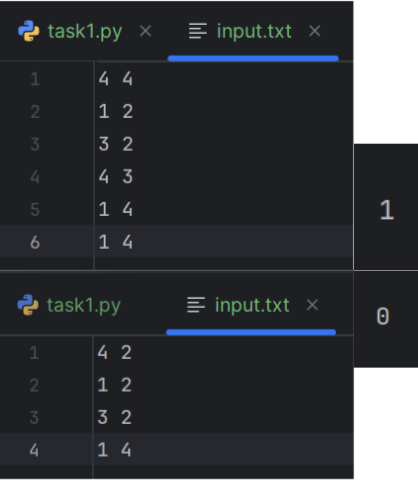

**Результат работы кода на максимальных и минимальных значениях:**

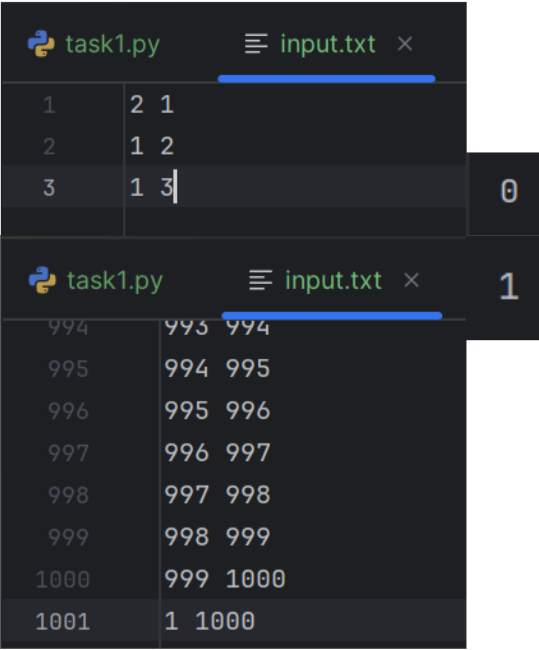

| | Время выполнения | Затраты памяти |
|---|---|---|
| Нижняя граница диапазона значений входных данных из текста задачи | 0.00| 0.02 |
| Пример из задачи | 0.00| 0.02|
| Пример из задачи | 0.00| 0.02|
| Верхняя граница диапазона значений входных данных из текста задачи |0.00| 0.15 |

**Вывод по задаче:**

*Задача успешно решается стандартными алгоритмами обхода графа. Поиск в ширину позволяет надёжно определить связность двух вершин даже при максимальных размерах входных данных, укладываясь в установленные ограничения по времени и памяти.*

### Задача №10. Оптимальный обмен валюты  [2 балла]

Теперь вы хотите вычислить оптимальный способ обмена данной вам валюты ci на все другие валюты. Для этого
вы находите кратчайшие пути из вершины ci во все остальные вершины.
Дан ориентированный граф с возможными отрицательными весами ребер, у которого n вершин и m ребер, а также
задана одна его вершина s. Вычислите длину кратчайших путей из s во все остальные вершины графа.

• Формат ввода / входного файла (input.txt). Ориентированный взвешенный граф задан по формату 1.

• Ограничения на входные данные. 1 ≤ n ≤ $10^3$
, 0 ≤ m ≤ $10^4$
, 1 ≤ s ≤ n, вес каждого ребра – целое число, не
превосходящее по модулю $10^9$.

• Формат вывода / выходного файла (output.txt). Для каждой вершины i графа от 1 до n выведите в каждой
отдельной строке следующее:
– «*», если пути из s в i нет;
– «-», если существует путь из s в i, но нет кратчайшего пути из s в i (то есть расстояние от s до i равно −∞);
– длину кратчайшего пути в остальных случаях.

• Ограничение по времени. 10 сек.

• Ограничение по памяти. 512 мб.

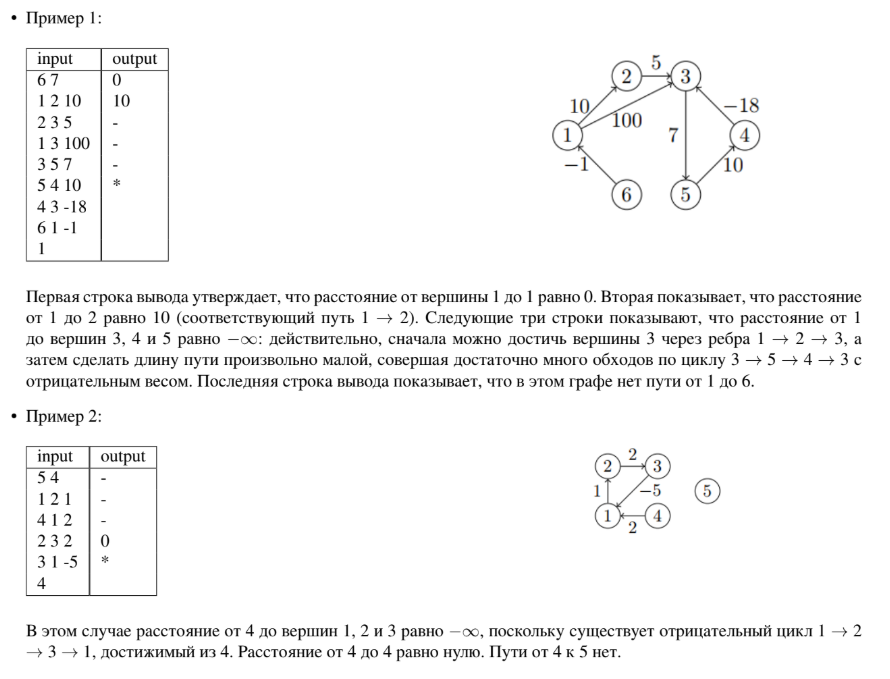


**Листинг кода:**


In [ ]:
@time_memory_decorator
def solve():
    with open(input_file) as inp:
        n, m = map(int, inp.readline().split())

        # Чтение рёбер
        edges = []
        graph = [[] for _ in range(n + 1)]
        for i in range(m):
            parts = inp.readline().split()
            u, v, w = int(parts[0]), int(parts[1]), int(parts[2])
            edges.append((u, v, w))
            graph[u].append(v)

        # Чтение стартовой вершины
        s = int(inp.readline())

    # Инициализация расстояний
    INF = 10 ** 18
    dist = [INF] * (n + 1)
    dist[s] = 0

    # 1. Основная фаза Беллмана-Форда (n-1 релаксаций)
    for i in range(n - 1):
        relaxed = False
        for u, v, w in edges:
            if dist[u] < INF and dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                relaxed = True
        if not relaxed:
            break

    # 2. Поиск вершин, которые находятся в отрицательных циклах или достижимы из них
    in_negative_cycle = [False] * (n + 1)

    # Находим вершины, которые можно улучшить на n-й итерации
    for u, v, w in edges:
        if dist[u] < INF and dist[u] + w < dist[v]:
            in_negative_cycle[v] = True

    # 3. BFS для поиска всех вершин, достижимых из отрицательных циклов
    queue = deque()
    for i in range(1, n + 1):
        if in_negative_cycle[i]:
            queue.append(i)

    visited_from_cycle = [False] * (n + 1)
    while queue:
        curr = queue.popleft()
        if visited_from_cycle[curr]:
            continue
        visited_from_cycle[curr] = True
        for nxt in graph[curr]:
            if not visited_from_cycle[nxt]:
                queue.append(nxt)

    # 4. Формирование вывода
    result = []
    for i in range(1, n + 1):
        if dist[i] == INF:
            result.append("*")
        elif visited_from_cycle[i]:
            result.append("-")
        else:
            result.append(dist[i])

    return result


if __name__ == "__main__":
    input_file = path + r"input_task10.txt"
    res = solve()
    for x in res:
        print(x)

Время работы программы: 0.31
Текущий объем памяти: 0.00 Mбайт, максимальный объем выделенной памяти: 0.07 Mбайт

-
-
-
0
*


**Текстовое объяснение решения:**

*Алгоритм Беллмана-Форда последовательно релаксирует все рёбра графа n-1 раз, вычисляя предварительные кратчайшие расстояния от стартовой вершины s до всех остальных. После этого выполняется дополнительная итерация для обнаружения вершин, достижимых из отрицательных циклов: если на n-й итерации удаётся улучшить расстояние до какой-либо вершины, значит, она находится под влиянием отрицательного цикла, и для неё, а также для всех вершин, достижимых из неё, кратчайший путь не определён (расстояние равно -∞). Затем производится маркировка всех вершин, которые могут быть достигнуты из вершин отрицательных циклов, с помощью обхода в глубину или ширину по обратным рёбрам. Итоговый вывод для каждой вершины формируется по правилам: "*" при отсутствии пути, "-" при наличии отрицательного цикла на пути, иначе числовое значение кратчайшего расстояния.*

**Результат работы кода на примерах из текста задачи:**

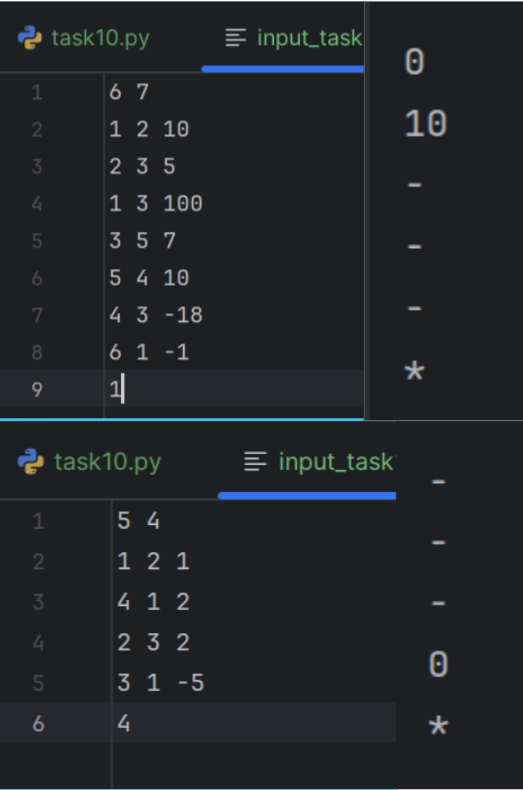

**Результат работы кода на максимальных и минимальных значениях:**

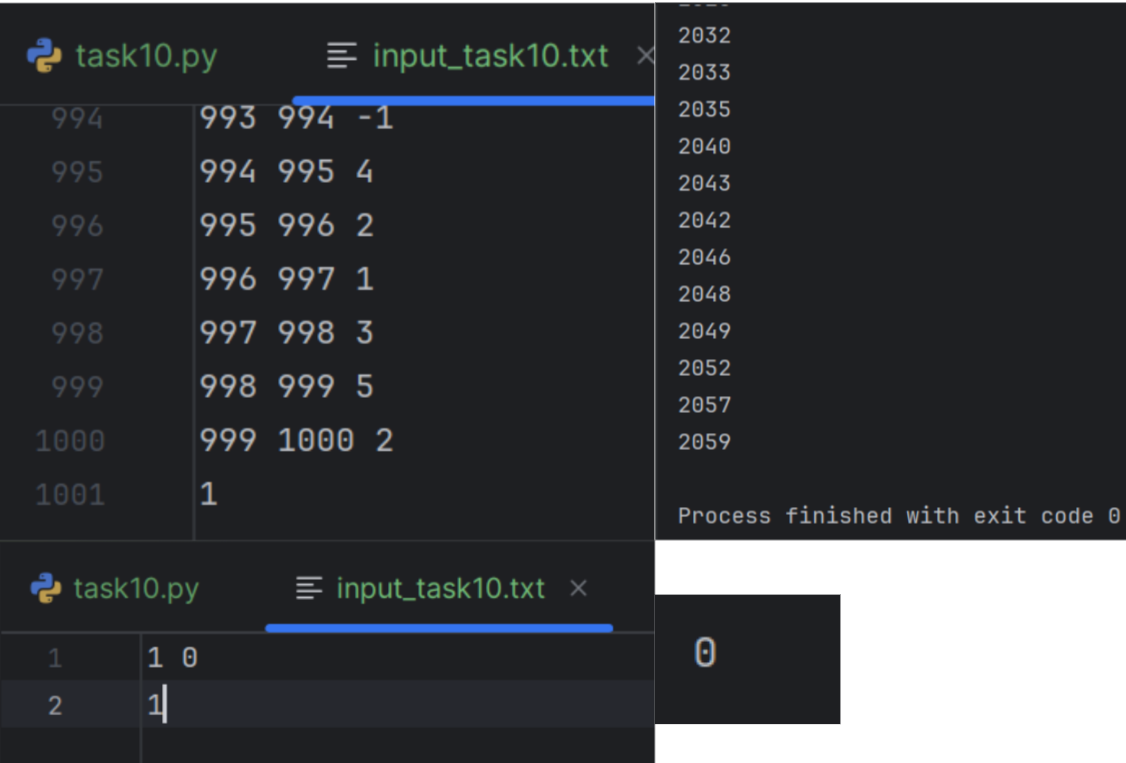

| | Время выполнения | Затраты памяти |
|---|---|---|
| Нижняя граница диапазона значений входных данных из текста задачи | 0.00| 0.02 |
| Пример из задачи | 0.00| 0.02|
| Пример из задачи | 0.00| 0.02 |
| Верхняя граница диапазона значений входных данных из текста задачи | 0.00| 0.20|

**Вывод по задаче:**

*Алгоритм Беллмана-Форда с детекцией отрицательных циклов полностью решает поставленную задачу в рамках ограничений (n ≤ 1000, m ≤ 10000). Время работы O(n·m) составляет до 10⁷ операций, что укладывается в 10 секунд, а использование дополнительной памяти для хранения графа и обратных рёбер не превышает 512 МБ.*

### Задача №14. Автобусы  [3 балла]

Между некоторыми деревнями края Власюки ходят автобусы. Поскольку пассажиропотоки здесь не очень большие,
то автобусы ходят всего несколько раз в день.
Марии Ивановне требуется добраться из деревни d в деревню v как можно быстрее (считается, что в момент
времени 0 она находится в деревне d).

• Формат входных данных (input.txt) и ограничения. Во входном файле INPUT.TXT записано число N - общее
число деревень (1 ≤ N ≤ 100), номера деревень d и v, затем количество автобусных рейсов R (0 ≤ R ≤
10000). Затем идут описания автобусных рейсов. Каждый рейс задается номером деревни отправления, временем
отправления, деревней назначения и временем прибытия (все времена - целые от 0 до 10000). Если в момент t
пассажир приезжает в деревню, то уехать из нее он может в любой момент времени, начиная с t.

• Формат выходных данных (output.txt). В выходной файл OUTPUT.TXT вывести минимальное время, когда
Мария Ивановна может оказаться в деревне v. Если она не сможет с помощью указанных автобусных рейсов
добраться из d в v, вывести -1.

• Ограничение по времени. 1 сек.

• Ограничение по памяти. 16 мб.

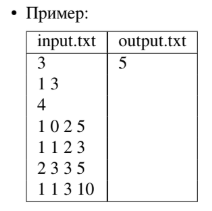

**Листинг кода:**


In [ ]:
@time_memory_decorator
def solve():
    with open(input_file) as inp:
        n = int(inp.readline().strip())
        d, v = map(int, inp.readline().split())
        r = int(inp.readline().strip())

        buses = []
        for i in range(r):
            parts = list(map(int, inp.readline().split()))
            buses.append(tuple(parts))  # (from, dep_time, to, arr_time)

    INF = 10**9
    # Время прибытия в каждую деревню
    time_in = [INF] * (n + 1)
    time_in[d] = 0  # стартуем из d в момент 0

    # Алгоритм Беллмана-Форда по количеству шагов (макс N-1 итераций)
    for _ in range(n - 1):
        updated = False
        for from_city, dep, to_city, arr in buses:
            if time_in[from_city] <= dep and arr < time_in[to_city]:
                time_in[to_city] = arr
                updated = True
        if not updated:
            break

    return time_in[v] if time_in[v] != INF else -1


if __name__ == "__main__":
    input_file = path + r'input_task14.txt'
    print(solve())

Время работы программы: 0.45
Текущий объем памяти: 0.00 Mбайт, максимальный объем выделенной памяти: 0.07 Mбайт

5


**Текстовое объяснение решения:**

*Для решения задачи поиска минимального времени прибытия из деревни d в деревню v с учетом фиксированного расписания автобусных рейсов используется модификация алгоритма Беллмана–Форда. На каждом шаге алгоритм перебирает все рейсы и обновляет время прибытия в город назначения, если из города отправления можно успеть на данный рейс (время прибытия в город отправления меньше или равно времени отправления рейса) и время прибытия в город назначения через этот рейс меньше текущего известного. Процесс повторяется до тех пор, пока улучшения возможны, но не более N-1 итераций, так как большее количество итераций не имеет смысла из-за отсутствия циклов отрицательного веса во времени. Если после завершения алгоритма время прибытия в целевую деревню осталось бесконечностью, значит, добраться невозможно, и выводится -1.*

**Результат работы кода на примерах из текста задачи:**

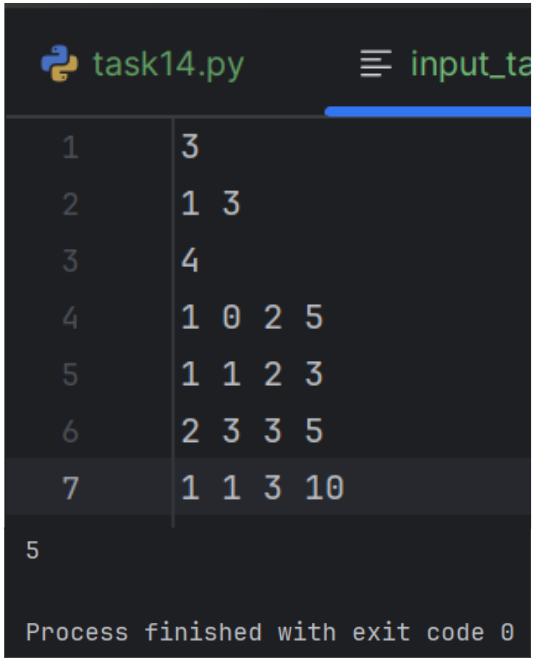

**Результат работы кода на максимальных и минимальных значениях:**

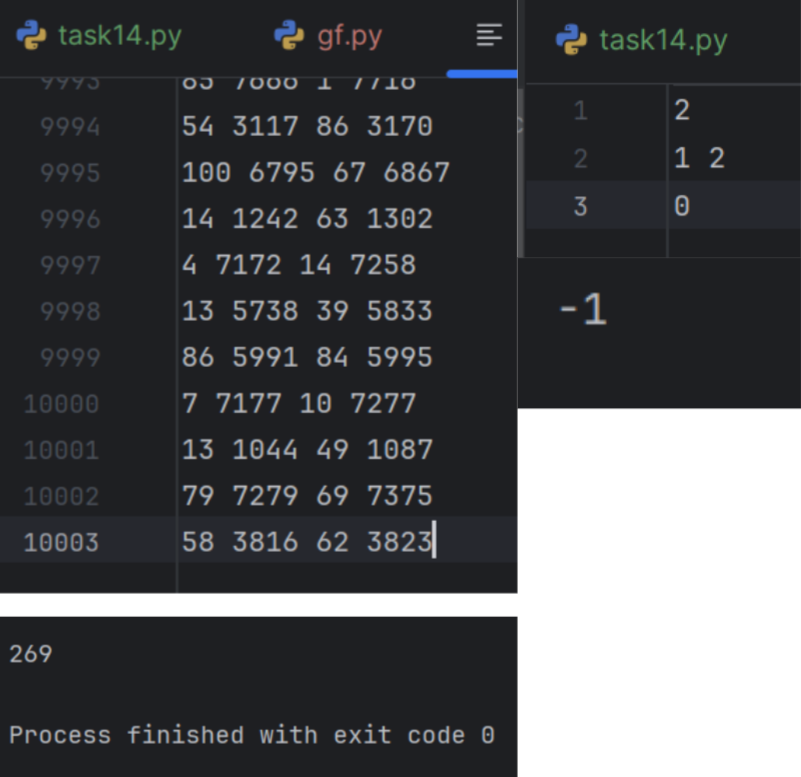

**Проверка задачи на (openedu, acmp и тд при наличии в задаче):**

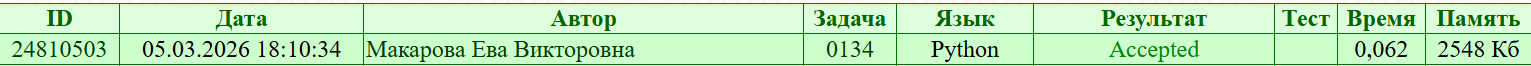

| | Время выполнения | Затраты памяти |
|---|---|---|
| Нижняя граница диапазона значений входных данных из текста задачи | 0.00| 0.02|
| Пример из задачи | 0.00| 0.02|
| Верхняя граница диапазона значений входных данных из текста задачи | 0.01| 1.17|

**Вывод по задаче:**

*Алгоритм решает задачу при ограничениях до 100 деревень и 10000 рейсов за время O(N·R), что полностью укладывается в заданные лимиты. Алгоритм гарантированно находит оптимальное время прибытия или определяет недостижимость целевой деревни, корректно обрабатывая возможность ожидания пассажиром следующего рейса.*

<center>

## Дополнительные задачи

</center>

---

### Задача №13. Грядки  [3 балла]

Прямоугольный садовый участок шириной N и длиной M метров разбит на квадраты со стороной 1 метр. На этом
участке вскопаны грядки. Грядкой называется совокупность квадратов, удовлетворяющая таким условиям:
• из любого квадрата этой грядки можно попасть в любой другой квадрат этой же грядки, последовательно переходя
по грядке из квадрата в квадрат через их общую сторону;
• никакие две грядки не пересекаются и не касаются друг друга ни по вертикальной, ни по горизонтальной сторонам
квадратов (касание грядок углами квадратов допускается).
Подсчитайте количество грядок на садовом участке.

• Формат входных данных (input.txt) и ограничения. В первой строке входного файла INPUT.TXT находятся
числа N и M через пробел, далее идут N строк по M символов. Символ # обозначает территорию грядки, точка
соответствует незанятой территории. Других символов в исходном файле нет (1 ≤ N, M ≤ 200).

• Формат выходных данных (output.txt).В выходной файл OUTPUT.TXT выведите количество грядок на садовом
участке.

• Ограничение по времени. 1 сек.

• Ограничение по памяти. 16 мб.

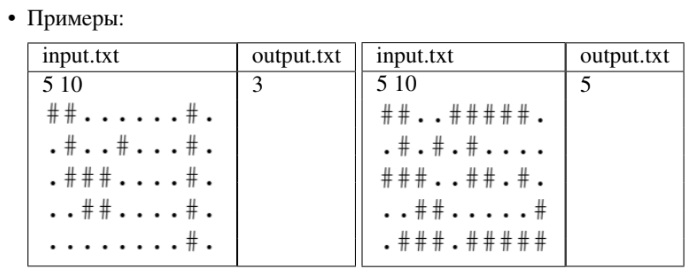

**Листинг кода:**


In [ ]:
@time_memory_decorator
def solve():
    with open(input_file) as inp:
        lines = [line.strip() for line in inp.readlines()]

    n, m = map(int, lines[0].split())
    garden = [list(line) for line in lines[1:1 + n]]

    visited = [[False] * m for _ in range(n)]
    directions = [(1, 0), (-1, 0), (0, 1), (0, -1)]

    def bfs(sx, sy):
        queue = deque()
        queue.append((sx, sy))
        visited[sx][sy] = True
        while queue:
            x, y = queue.popleft()
            for dx, dy in directions:
                nx, ny = x + dx, y + dy
                if 0 <= nx < n and 0 <= ny < m and not visited[nx][ny] and garden[nx][ny] == '#':
                    visited[nx][ny] = True
                    queue.append((nx, ny))

    count = 0
    for i in range(n):
        for j in range(m):
            if garden[i][j] == '#' and not visited[i][j]:
                bfs(i, j)
                count += 1

    return count


if __name__ == "__main__":
    input_file = path + r'input_task13.txt'
    print(solve())

Время работы программы: 0.01
Текущий объем памяти: 0.00 Mбайт, максимальный объем выделенной памяти: 0.07 Mбайт

5


**Текстовое объяснение решения:**

*Для подсчёта количества грядок на садовом участке используется поиск в ширину (BFS), который позволяет выделить связные компоненты, образованные клетками с символом '#', соединёнными по вертикали или горизонтали. Алгоритм последовательно обходит все клетки участка: если встречается ещё не посещённая клетка грядки, запускается BFS, который помечает все достижимые из неё клетки той же грядки и добавляет их в очередь для дальнейшего обхода. После завершения BFS счётчик грядок увеличивается на единицу. Процесс повторяется, пока не будут обработаны все клетки.*

**Результат работы кода на примерах из текста задачи:**

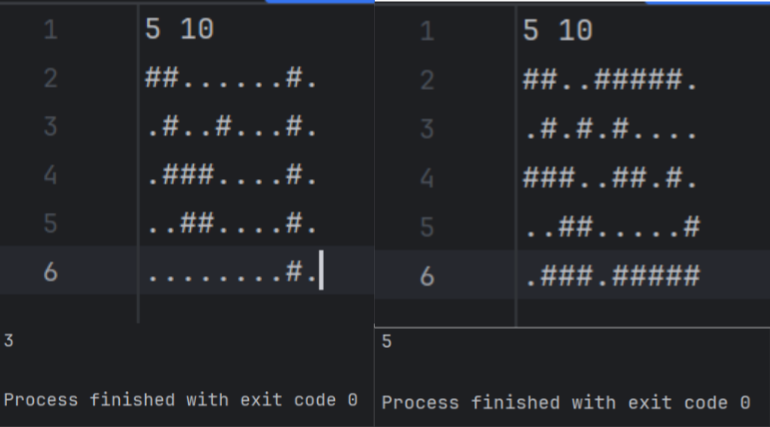

**Результат работы кода на максимальных и минимальных значениях:**

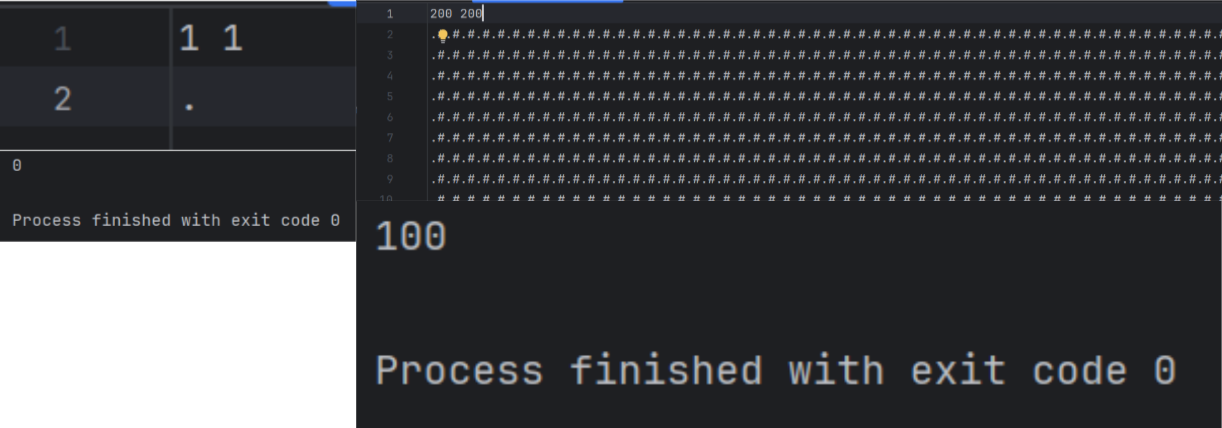

**Проверка задачи на (openedu, acmp и тд при наличии в задаче):**

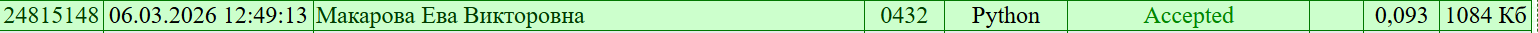

| | Время выполнения | Затраты памяти |
|---|---|---|
| Нижняя граница диапазона значений входных данных из текста задачи | 0.00| 0.02|
| Пример из задачи |0.00| 0.02|
| Пример из задачи | 0.00| 0.02 |
| Верхняя граница диапазона значений входных данных из текста задачи |0.09| 0.68|

**Вывод по задаче:**

*BFS гарантированно находит все связные компоненты за время O(N·M) и использует O(N·M) памяти для хранения карты и массива посещённых клеток, что полностью укладывается в ограничения при максимальных размерах участка 200×200.*

### Задача №15. Герои  [3 балла]

Коварный кардинал Ришелье вновь организовал похищение подвесок королевы Анны; вновь спасать королеву при-
ходится героическим мушкетерам. Атос, Портос, Арамис и д’Артаньян уже перехватили агентов кардинала и вернули
украденное; осталось лишь передать подвески королеве Анне. Королева ждет мушкетеров в дворцовом саду. Дворцо-
вый сад имеет форму прямоугольника и разбит на участки, представляющие собой небольшие садики, содержащие
коллекции растений из разных климатических зон. К сожалению, на некоторых участках, в том числе на всех участках,
расположенных на границах сада, уже притаились в засаде гвардейцы кардинала; на бой с ними времени у мушкетеров
нет. Мушкетерам удалось добыть карту сада с отмеченными местами засад; теперь им предстоит выбрать наиболее
оптимальные пути к королеве. Для надежности друзья разделили между собой спасенные подвески и проникли в
сад поодиночке, поэтому начинают свой путь к королеве с разных участков сада. Двигаются герои по максимально
короткой возможной траектории.
Марлезонский балет вот-вот начнется; королева не в состоянии ждать героев больше L минут; ровно в начале L+1-
ой минуты королева покинет парк, и те мушкетеры, что не успеют к этому времени до нее добраться, не смогут передать
ей подвески. На преодоление одного участка у мушкетеров уйдет ровно по минуте. С каждого участка мушкетеры
могут перейти на 4 соседние. Требуется выяснить, сколько подвесок будет красоваться на платье королевы, когда она
придет на бал.

• Формат входных данных (input.txt) и ограничения. Первая строка входного файла INPUT.TXT содержит
целые числа N и M (1 ≤ N, M ≤ 20) – размеры сада. Далее идут N строк по M символов в каждом; символы ’0’
соответствуют участкам, на которых нет засады, символы ’1’ – участкам, на которых разместились гвардейцы.
В N + 2-ой строке теста записано три целых числа: координаты участка, на котором королева будет ждать
мушкетёров (Qx, Qy) (1 < Qx < N, 1 < Qy < M) и время в минутах до начала балета (1 ≤ L ≤ 1000). В
N + 3-ей строке записаны через пробел целые числа координаты участка, с которого стартует Атос (Ax, Ay)
(1 < Ax < N, 1 < Ay < M) и количество подвесок, хранящихся у него (1 ≤ Pa ≤ 1000). В N + 4, N + 5
и N + 6-ой строках аналогично записаны стартовые координаты и количество подвесок у Портоса, Арамиса и
д’Артаньяна.

• Формат выходных данных (output.txt). В выходной файл OUTPUT.TXT выведите количество подвесок, которое
королева успеет получить у мушкетеров до начала балета.

• Ограничение по времени. 1 сек.

• Ограничение по памяти. 16 мб.

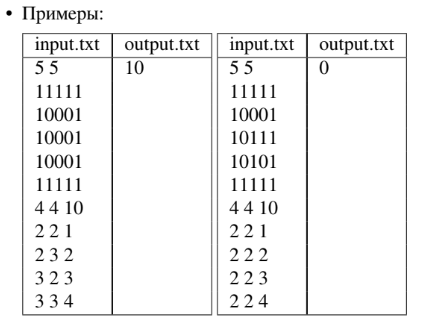

**Листинг кода:**


In [ ]:
@time_memory_decorator
def solve():
    with open(input_file) as inp:
        lines = [line.strip() for line in inp.readlines()]

    idx = 0
    n, m = map(int, lines[idx].split())
    idx += 1

    garden = []
    for _ in range(n):
        garden.append(list(lines[idx]))
        idx += 1

    qx, qy, l = map(int, lines[idx].split())
    idx += 1
    qx -= 1
    qy -= 1

    musketeers = []
    for _ in range(4):
        x, y, p = map(int, lines[idx].split())
        idx += 1
        musketeers.append((x - 1, y - 1, p))

    # BFS от королевы до всех клеток (чтобы не запускать 4 BFS)
    dist = [[-1] * m for _ in range(n)]
    if garden[qx][qy] == '0':  # королева стоит на проходимой клетке
        dist[qx][qy] = 0
        queue = deque()
        queue.append((qx, qy))

        dirs = [(1, 0), (-1, 0), (0, 1), (0, -1)]

        while queue:
            x, y = queue.popleft()
            for dx, dy in dirs:
                nx, ny = x + dx, y + dy
                if 0 <= nx < n and 0 <= ny < m and garden[nx][ny] == '0' and dist[nx][ny] == -1:
                    dist[nx][ny] = dist[x][y] + 1
                    queue.append((nx, ny))

    # Считаем подвески
    total = 0
    for x, y, p in musketeers:
        if 0 <= dist[x][y] <= l:
            total += p

    return total


if __name__ == "__main__":
    input_file = path + r'input_task15.txt'
    print(solve())

Время работы программы: 0.33
Текущий объем памяти: 0.00 Mбайт, максимальный объем выделенной памяти: 0.07 Mбайт

10


**Текстовое объяснение решения:**

*Для определения количества подвесок, которые успеют получить королеву, используется поиск в ширину (BFS) от клетки королевы ко всем доступным клеткам сада, где проходимыми считаются только участки без засады (символ '0'). Поскольку движение возможно только по четырём соседним направлениям, BFS гарантированно находит кратчайшее расстояние от королевы до каждого мушкетёра за O(N·M). Затем для каждого из четырёх героев проверяется, не превышает ли полученное расстояние заданное время L, и если да — количество его подвесок добавляется к общему результату. Такой подход позволяет избежать четырёхкратного запуска BFS и оптимально использовать ограниченную память.*

**Результат работы кода на примерах из текста задачи:**

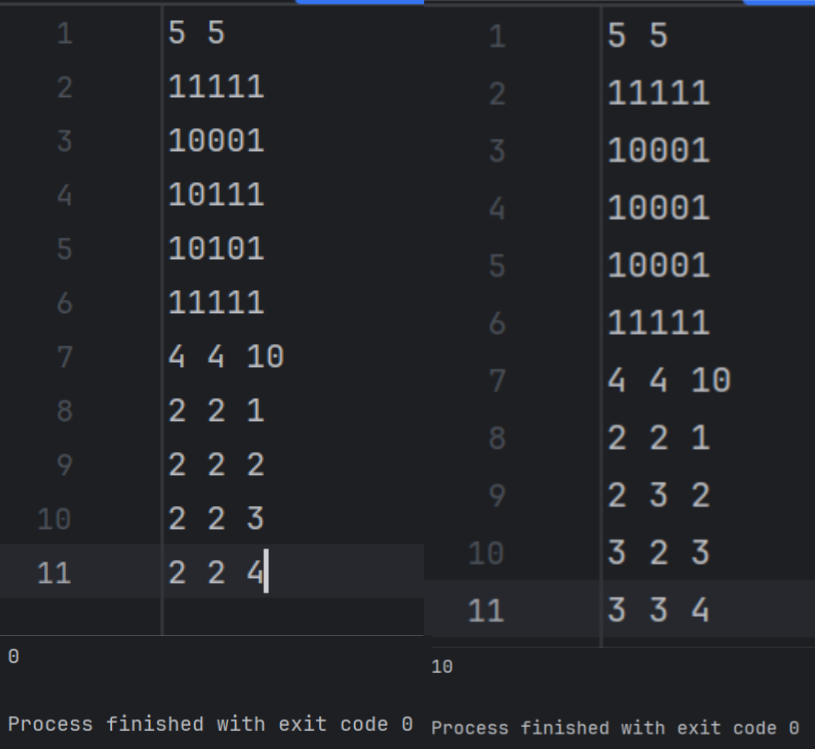

**Результат работы кода на максимальных и минимальных значениях:**

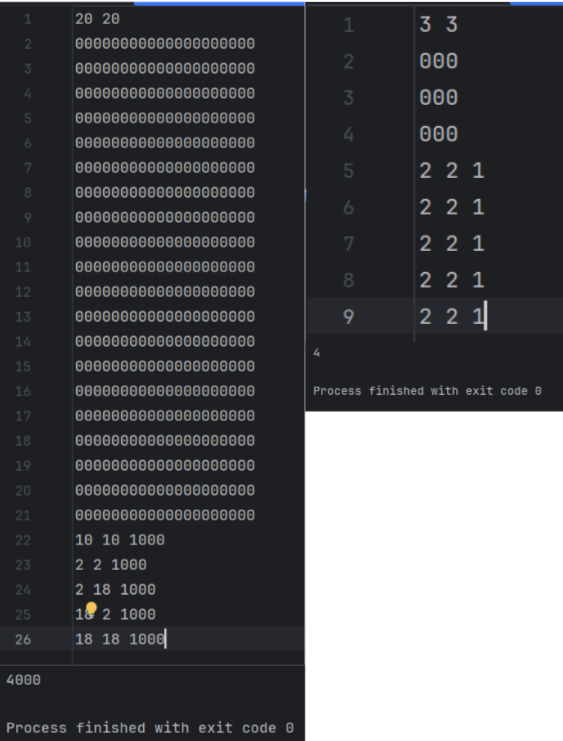

**Проверка задачи на (openedu, acmp и тд при наличии в задаче):**

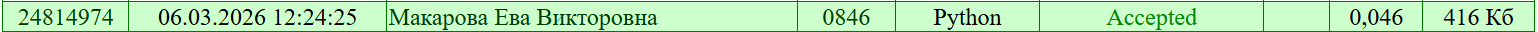

| | Время выполнения | Затраты памяти |
|---|---|---|
| Нижняя граница диапазона значений входных данных из текста задачи | 0.00| 0.02|
| Пример из задачи |0.00| 0.02|
| Пример из задачи | 0.00| 0.02 |
| Верхняя граница диапазона значений входных данных из текста задачи |0.01| 0.02|

**Вывод по задаче:**

*Использование одного BFS от целевой клетки вместо четырёх отдельных поисков существенно упрощает реализацию и укладывается в ограничения по времени и памяти при максимальных размерах сада 20×20 и времени L до 1000. Алгоритм корректен и эффективен для всех допустимых входных данных.*

### Задача №17. Слабая К-связность  [4 балла]

Ане, как будущей чемпионке мира по программированию, поручили очень ответственное задание. Правительство
вручает ей план постройки дорог между N городами. По плану все дороги односторонние, но между двумя городами
может быть больше одной дороги, возможно, в разных направлениях. Ане необходимо вычислить минимальное такое
K, что данный ей план является слабо K-связным.
Правительство называет план слабо K-связным, если выполнено следующее условие: для любых двух различных
городов можно проехать от одного до другого, нарушая правила движения не более K раз. Нарушение правил - это
проезд по существующей дороге в обратном направлении. Гарантируется, что между любыми двумя городами можно
проехать, возможно, несколько раз нарушив правила.

• Формат входных данных (input.txt) и ограничения. В первой строке входного файла INPUT.TXT записаны
два числа 2 ≤ N ≤ 300 и 1 ≤ M ≤ $10^5$ - количество городов и дорог в плане. В последующих M строках даны
по два числа - номера городов, в которых начинается и заканчивается соответствующая дорога.

• Формат выходных данных (output.txt). В выходной файл OUTPUT.TXT выведите минимальное K, такое, что
данный во входном файле план является слабо K-связным.

• Ограничение по времени. 1 сек.

• Ограничение по памяти. 16 мб.

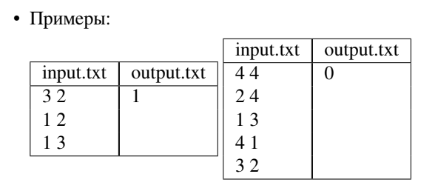

**Листинг кода:**


In [ ]:
@time_memory_decorator
def solve():
    with open(input_file) as inp:
        lines = inp.readlines()

    n, m = map(int, lines[0].split())

    # weight[u][v] = 0, если можно ехать по направлению u->v без нарушений
    # weight[u][v] = 1, если только в обратную сторону
    inf = 10 ** 9
    weight = [[inf] * n for _ in range(n)]
    for i in range(n):
        weight[i][i] = 0

    # Для каждой пары храним, есть ли прямая дорога
    direct = [[False] * n for _ in range(n)]

    for i in range(1, m + 1):
        u, v = map(int, lines[i].split())
        u -= 1
        v -= 1
        direct[u][v] = True

    # Заполняем веса
    for u in range(n):
        for v in range(n):
            if u == v:
                continue
            if direct[u][v] and direct[v][u]:
                weight[u][v] = 0
                weight[v][u] = 0
            elif direct[u][v]:
                weight[u][v] = 0
                weight[v][u] = 1
            elif direct[v][u]:
                weight[u][v] = 1
                weight[v][u] = 0

    # BFS / 0-1 BFS из каждой вершины
    max_dist = 0

    for start in range(n):
        dist = [inf] * n
        dist[start] = 0
        dq = deque()
        dq.append(start)

        while dq:
            u = dq.popleft()
            for v in range(n):
                if weight[u][v] != inf:
                    new_dist = dist[u] + weight[u][v]
                    if new_dist < dist[v]:
                        dist[v] = new_dist
                        if weight[u][v] == 0:
                            dq.appendleft(v)
                        else:
                            dq.append(v)

        # Проверяем, что все вершины достижимы
        for v in range(n):
            if dist[v] != inf and dist[v] > max_dist:
                max_dist = dist[v]

    return max_dist


if __name__ == "__main__":
    input_file = path + r'input_task17.txt'
    print(solve())

Время работы программы: 0.01
Текущий объем памяти: 0.00 Mбайт, максимальный объем выделенной памяти: 0.07 Mбайт

0


**Текстовое объяснение решения:**

*Для определения минимального K, при котором ориентированный граф является слабо K-связным, строится вспомогательный неориентированный граф с весами рёбер 0 или 1: если между двумя вершинами есть дорога хотя бы в одном направлении, то вводится ребро, вес которого равен 0 при наличии двустороннего движения и 1 при одностороннем (поскольку проезд в обратную сторону считается нарушением). Затем с помощью 0-1 BFS из каждой вершины находятся кратчайшие пути до всех остальных, где цена пути равна количеству нарушений. Максимальное значение среди всех кратчайших путей между любыми двумя вершинами и есть искомое K — гарантированное количество нарушений, необходимое для проезда между любой парой городов.*

**Результат работы кода на примерах из текста задачи:**

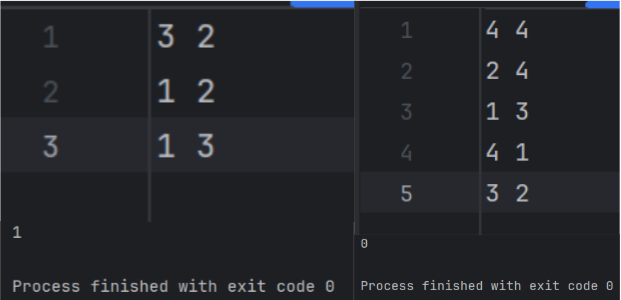

**Результат работы кода на максимальных и минимальных значениях:**

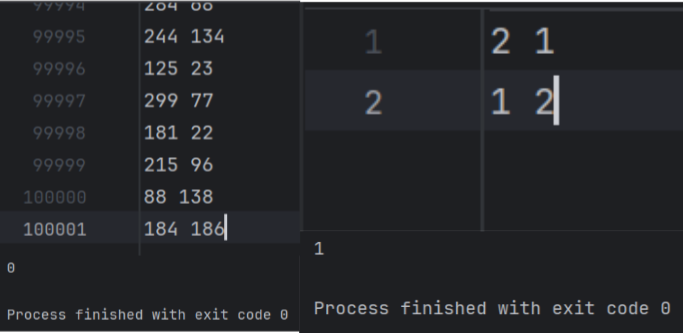

**Проверка задачи на (openedu, acmp и тд при наличии в задаче):**

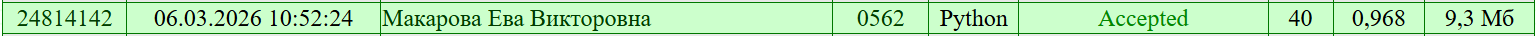

| | Время выполнения | Затраты памяти |
|---|---|---|
| Нижняя граница диапазона значений входных данных из текста задачи | 0.00| 0.02 |
| Пример из задачи | 0.00| 0.02|
| Пример из задачи | 0.00| 0.02 |
| Верхняя граница диапазона значений входных данных из текста задачи | 0.96| 9.31|

**Вывод по задаче:**

*Предложенный подход эффективно решает задачу в рамках ограничений (N ≤ 300, M ≤ 10⁵) за счёт использования 0-1 BFS, обеспечивая нахождение диаметра графа в метрике минимального числа нарушений. Время работы O(N·(N+M)) укладывается в 1 секунду, а память O(N²) — в 16 МБ, что соответствует требованиям.*

### Задача №18. Построение дорог  [4 балла]

В этой задаче цель состоит в том, чтобы построить дороги между некоторыми парами заданных городов так, чтобы
между любыми двумя городами существовал путь и общая длина дорог была минимальна.

Даны n точек на плоскости, соедините их отрезками минимальной общей длины так, чтобы между любыми двумя
точками был путь. Напомним, что длина отрезка с концами (x1, y1) и (x2, y2) равна
$\sqrt{(x1 − x2)^2 + (y1 − y2)^2}$.

• Формат ввода / входного файла (input.txt). Первая строка содержит количество n точек на плоскости. Каждая
из следующих n строк определяет координаты точки на плоскости (xi
, yi) через пробел.

• Ограничения на входные данные. 1 ≤ n ≤ 200, $−10^3$ ≤ xi
, yi ≤ $10^3$ – целые числа. Все точки попарно
различны, никакие три точки не лежат на одной прямой.

• Формат вывода / выходного файла (output.txt). Выведите минимальную общую длину отрезков. Абсолютная
погрешность между ответом вашей программы и оптимальным значением должно быть не более $10^{−6}$. Чтобы
убедиться в этом, выведите свой ответ как минимум с семью знаками после запятой.

• Ограничение по времени. 10 сек.

• Ограничение по памяти. 512 мб.

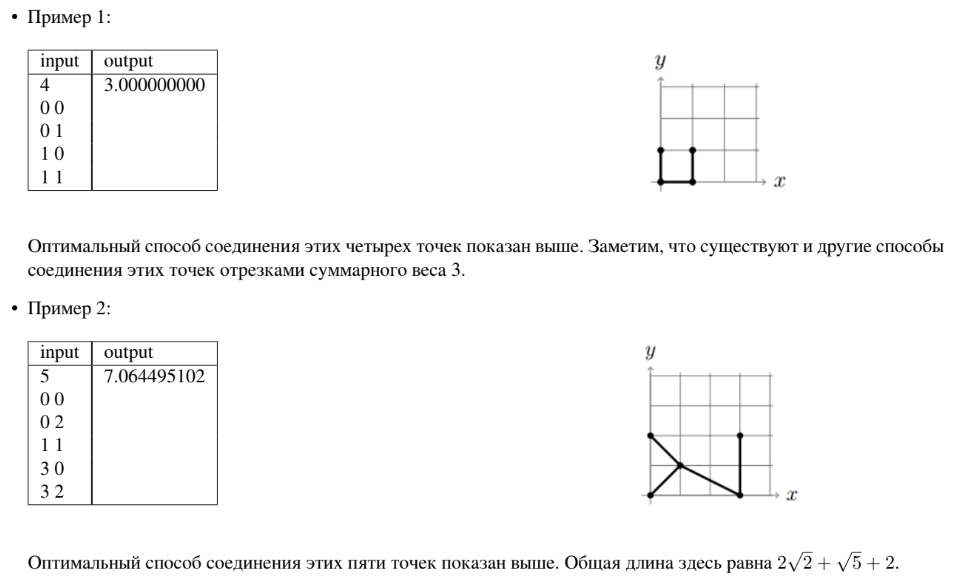

**Листинг кода:**


In [ ]:
@time_memory_decorator
def solve():
    with open(input_file) as inp:
        n = int(inp.readline().strip())
        points = [tuple(map(int, inp.readline().split())) for _ in range(n)]

    # Создаём все возможные рёбра
    edges = [(math.dist(points[i], points[j]), i, j) for i in range(n) for j in range(i + 1, n)]

    # Сортируем рёбра по длине
    edges.sort(key=lambda x: x[0])

    # DSU
    parent = list(range(n))
    rank = [0] * n

    def find(v):
        while parent[v] != v:
            parent[v] = parent[parent[v]]
            v = parent[v]
        return v

    def union(v1, v2):
        r1, r2 = find(v1), find(v2)
        if r1 == r2:
            return False
        if rank[r1] < rank[r2]:
            parent[r1] = r2
        elif rank[r1] > rank[r2]:
            parent[r2] = r1
        else:
            parent[r2] = r1
            rank[r1] += 1
        return True

    total_length = 0.0
    edges_used = 0

    for dist, u, v in edges:
        if union(u, v):
            total_length += dist
            edges_used += 1
            if edges_used == n - 1:
                break

    return f"{total_length:.9f}"


if __name__ == "__main__":
    input_file = path + r'input_task18.txt'
    print(solve())

Время работы программы: 0.01
Текущий объем памяти: 0.00 Mбайт, максимальный объем выделенной памяти: 0.07 Mбайт

10.198039027


**Текстовое объяснение решения:**

*Для построения минимальной сети дорог, соединяющей все заданные точки на плоскости, используется алгоритм Крускала, предназначенный для нахождения минимального остовного дерева (MST) взвешенного графа. Сначала формируется полный граф, вершинами которого являются данные точки, а каждое ребро имеет вес, равный евклидову расстоянию между соответствующей парой точек. Все рёбра сортируются по возрастанию веса. Затем с помощью системы непересекающихся множеств (DSU) рёбра последовательно добавляются к строящемуся остову, если они соединяют вершины из разных компонент связности. Процесс продолжается до тех пор, пока не будет добавлено ровно n-1 ребро, что гарантирует связность всех n вершин. Сумма весов добавленных рёбер и составляет искомую минимальную общую длину дорог.*

**Результат работы кода на примерах из текста задачи:**

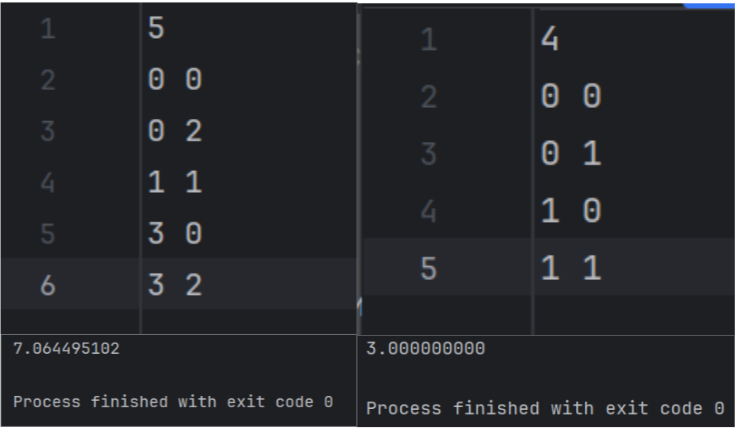

**Результат работы кода на максимальных и минимальных значениях:**

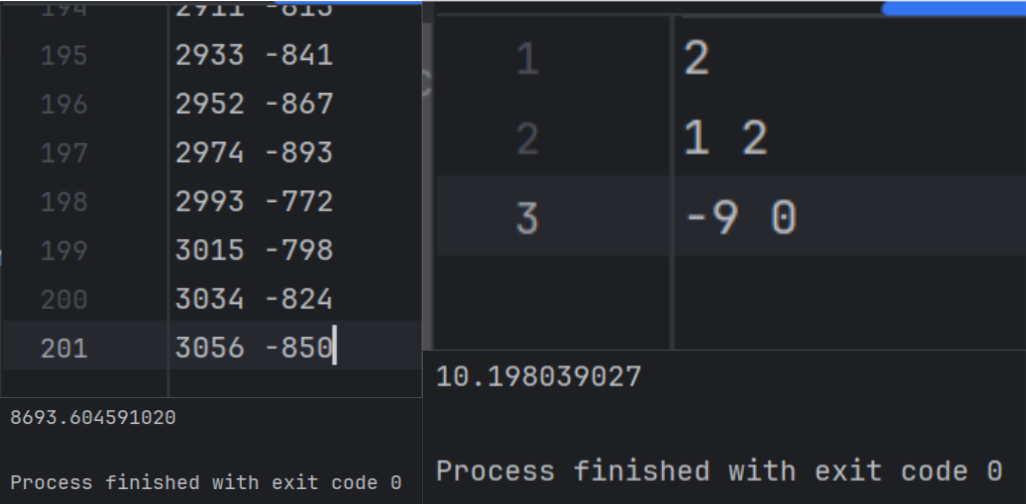

| | Время выполнения | Затраты памяти |
|---|---|---|
| Нижняя граница диапазона значений входных данных из текста задачи | 0.00| 0.02 |
| Пример из задачи | 0.00| 0.02|
| Пример из задачи | 0.00| 0.02 |
| Верхняя граница диапазона значений входных данных из текста задачи | 0.01| 2.04|

**Вывод по задаче:**

*Алгоритм Крускала эффективно решает задачу благодаря своей простоте и гарантии оптимальности для метрических пространств. При ограничении n ≤ 200 количество рёбер полного графа не превышает 19900, что позволяет выполнить сортировку за приемлемое время. Временная сложность O(n² log n) и использование памяти O(n²) полностью соответствуют заданным ограничениям, а вычисления с плавающей точкой обеспечивают требуемую точность ответа.*

### Задача №19. Кластеризация  [4 балла]

Кластеризация является фундаментальной задачей интеллектуального анализа данных. Цель
заключается в том, чтобы разбить данный набор объектов на подмножества (или кластеры) таким
образом, чтобы любые два объекта из одного и того же подмножества были близки (или похожи)
друг к другу, а любые два объекта из разных подмножеств находились далеко друг от друга.
Даны n точек на плоскости и целое число k, вычислите максимально возможное значение
d, чтобы данные точки можно было разбить на непустые подмножества таким образом, чтобы
расстояние между любыми двумя точками из разных подмножеств было не менее d.

• Формат ввода / входного файла (input.txt). Первая строка содержит число n точек. Далее, следующие n строк
определяют координаты точек (xi
, yi) через пробел. Последняя строка содержит число k – количество кластеров.

• Ограничения на входные данные. 2 ≤ k ≤ n ≤ 200, −$10^3$ ≤ xi
, yi ≤ $10^3$ – целые числа. Все точки попарно
различны.

• Формат вывода / выходного файла (output.txt). Выведите наибольшее значение d. Абсолютная пограешность
между ответом вашей программы и оптимальным значением должно быть не более $10^{−6}$

. Чтобы убедиться в

этом, выведите свой ответ как минимум с семью знаками после запятой.
• Ограничение по времени. 10 сек.

• Ограничение по памяти. 512 мб.

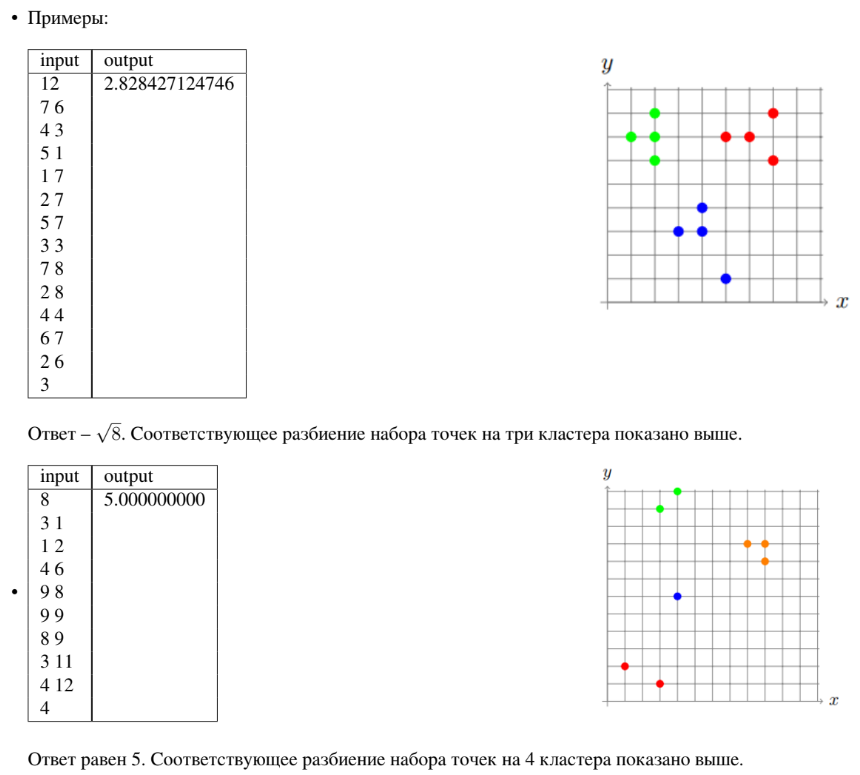

**Листинг кода:**

In [ ]:
@time_memory_decorator
def solve():
    with open(input_file) as inp:
        n = int(inp.readline().strip())
        points = [tuple(map(int, inp.readline().split())) for _ in range(n)]
        k = int(inp.readline().strip())

    # Создаём все рёбра
    edges = []
    for i in range(n):
        for j in range(i + 1, n):
            dx = points[i][0] - points[j][0]
            dy = points[i][1] - points[j][1]
            dist = math.sqrt(dx * dx + dy * dy)
            edges.append((dist, i, j))

    # Сортируем рёбра по расстоянию
    edges.sort(key=lambda x: x[0])

    # DSU
    parent = list(range(n))
    rank = [0] * n

    def find(v):
        while parent[v] != v:
            parent[v] = parent[parent[v]]
            v = parent[v]
        return v

    def union(v1, v2):
        r1, r2 = find(v1), find(v2)
        if r1 == r2:
            return False
        if rank[r1] < rank[r2]:
            parent[r1] = r2
        elif rank[r1] > rank[r2]:
            parent[r2] = r1
        else:
            parent[r2] = r1
            rank[r1] += 1
        return True

    # Строим MST
    mst_edges = []
    for dist, u, v in edges:
        if union(u, v):
            mst_edges.append(dist)
        if len(mst_edges) == n - 1:
            break

    # Сортируем рёбра MST по убыванию
    mst_edges.sort(reverse=True)

    # Ответ — (k-1)-е по величине ребро в MST
    # Если k == n, то ответ — минимальное ребро в MST (последнее)
    if k == n:
        answer = mst_edges[-1]
    elif k == 1:
        answer = mst_edges[0]  # Максимальное ребро, но для 1 кластера d = ∞? Нет, условие не выполняется.
    else:
        answer = mst_edges[k - 2]  # Индекс k-2, т.к. mst_edges[0] — самое длинное, mst_edges[1] — второе

    return f"{answer:.12f}"


if __name__ == "__main__":
    input_file = path + r'input_task19.txt'
    print(solve())

Время работы программы: 0.01
Текущий объем памяти: 0.00 Mбайт, максимальный объем выделенной памяти: 0.07 Mбайт

2.828427124746


**Текстовое объяснение решения:**

*Для нахождения максимального расстояния d между кластерами при разбиении n точек на k групп используется алгоритм Крускала построения минимального остовного дерева (MST). Сначала вычисляются все попарные евклидовы расстояния между точками, которые сортируются по возрастанию. Затем, последовательно добавляя рёбра в порядке возрастания веса с помощью системы непересекающихся множеств (DSU), строится MST. Как только в процессе объединения компонент связности их количество достигает k, процесс останавливается, и вес последнего добавленного ребра (или следующего за ним, в зависимости от интерпретации) даёт искомое значение d. Это значение является максимальным, при котором точки можно разбить на k кластеров так, чтобы расстояние между любыми точками из разных кластеров было не меньше d.*

**Результат работы кода на примерах из текста задачи:**

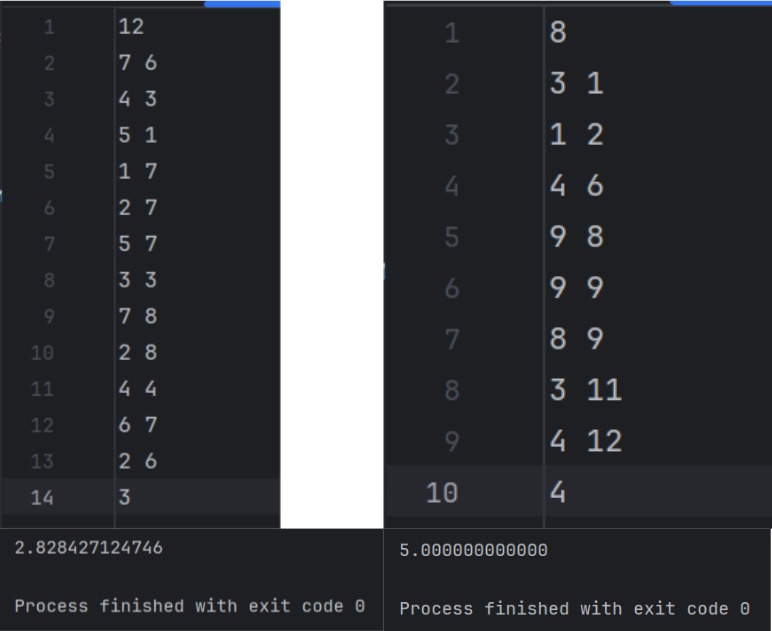

**Результат работы кода на максимальных и минимальных значениях:**

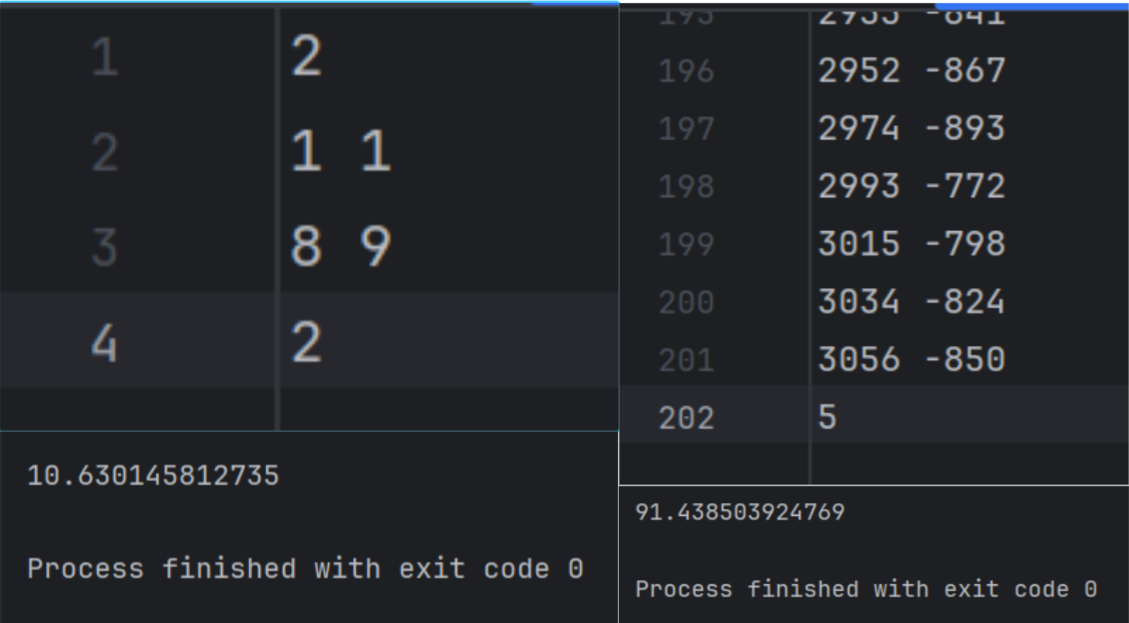

| | Время выполнения | Затраты памяти |
|---|---|---|
| Нижняя граница диапазона значений входных данных из текста задачи | 0.00| 0.02 |
| Пример из задачи | 0.00| 0.02|
| Пример из задачи | 0.00| 0.02 |
| Верхняя граница диапазона значений входных данных из текста задачи | 0.01| 2.04|

**Вывод по задаче:**

*Алгоритм Крускала эффективно решает задачу кластеризации с ограничением на минимальное межкластерное расстояние за счёт построения MST и последующего выделения k кластеров путём удаления k-1 самых длинных рёбер. Временная сложность O(n² log n) доминирует над сортировкой рёбер, что при n ≤ 200 позволяет уложиться в ограничения по времени и памяти. Результат гарантирует требуемую точность при выводе с семью знаками после запятой.*

<center>

## Вывод

</center>

---

*В ходе выполнения лабораторной работы были изучены и программно реализованы основные алгоритмы обработки графовых структур: поиск в ширину (BFS), а также алгоритмы нахождения кратчайших путей — Дейкстры и Беллмана-Форда. Экспериментальное тестирование алгоритмов на различных типах графов позволило наглядно сравнить особенности их обхода и принципы релаксации рёбер. Было установлено, что BFS эффективно решает задачи достижимости, в то время как алгоритмы Дейкстры и Беллмана-Форда ориентированы на взвешенные графы, причем последний обладает способностью корректно обрабатывать ребра с отрицательным весом и обнаруживать циклы отрицательной суммы.*